In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [3]:
data = pd.read_csv('train_FD003.txt', sep=' ', header=None)
columns = ["unit_number","time_in_cycles",
           "setting1","setting2","setting3"] + \
          [f"sensor{i}" for i in range(1,22)]

data = data.iloc[:, :len(columns)]
data.columns = columns
data.to_csv('train_FD003.csv', index=False)

In [4]:
data

,unit_number,time_in_cycles,setting1,setting2,setting3,sensor1,sensor2,sensor3,sensor4,sensor5,...,sensor12,sensor13,sensor14,sensor15,sensor16,sensor17,sensor18,sensor19,sensor20,sensor21
0,1,1,-0.0005,0.0004,100.0,518.67,642.36,1583.23,1396.84,14.62,...,522.31,2388.01,8145.32,8.4246,0.03,391,2388,100.0,39.11,23.3537
1,1,2,0.0008,-0.0003,100.0,518.67,642.50,1584.69,1396.89,14.62,...,522.42,2388.03,8152.85,8.4403,0.03,392,2388,100.0,38.99,23.4491
2,1,3,-0.0014,-0.0002,100.0,518.67,642.18,1582.35,1405.61,14.62,...,522.03,2388.00,8150.17,8.3901,0.03,391,2388,100.0,38.85,23.3669
3,1,4,-0.0020,0.0001,100.0,518.67,642.92,1585.61,1392.27,14.62,...,522.49,2388.08,8146.56,8.3878,0.03,392,2388,100.0,38.96,23.2951
4,1,5,0.0016,0.0000,100.0,518.67,641.68,1588.63,1397.65,14.62,...,522.58,2388.03,8147.80,8.3869,0.03,392,2388,100.0,39.14,23.4583
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24715,100,148,-0.0016,-0.0003,100.0,518.67,643.78,1596.01,1424.11,14.62,...,519.66,2388.30,8138.08,8.5036,0.03,394,2388,100.0,38.44,22.9631
24716,100,149,0.0034,-0.0003,100.0,518.67,643.29,1596.38,1429.14,14.62,...,519.91,2388.28,8144.36,8.5174,0.03,395,2388,100.0,38.50,22.9746
24717,100,150,-0.0016,0.0004,100.0,518.67,643.84,1604.53,1431.41,14.62,...,519.44,2388.24,8135.95,8.5223,0.03,396,2388,100.0,38.39,23.0682
24718,100,151,-0.0023,0.0004,100.0,518.67,643.94,1597.56,1426.57,14.62,...,520.01,2388.26,8141.24,8.5148,0.03,395,2388,100.0,38.31,23.0753


In [5]:
data.head()

,unit_number,time_in_cycles,setting1,setting2,setting3,sensor1,sensor2,sensor3,sensor4,sensor5,...,sensor12,sensor13,sensor14,sensor15,sensor16,sensor17,sensor18,sensor19,sensor20,sensor21
0,1,1,-0.0005,0.0004,100.0,518.67,642.36,1583.23,1396.84,14.62,...,522.31,2388.01,8145.32,8.4246,0.03,391,2388,100.0,39.11,23.3537
1,1,2,0.0008,-0.0003,100.0,518.67,642.50,1584.69,1396.89,14.62,...,522.42,2388.03,8152.85,8.4403,0.03,392,2388,100.0,38.99,23.4491
2,1,3,-0.0014,-0.0002,100.0,518.67,642.18,1582.35,1405.61,14.62,...,522.03,2388.00,8150.17,8.3901,0.03,391,2388,100.0,38.85,23.3669
3,1,4,-0.0020,0.0001,100.0,518.67,642.92,1585.61,1392.27,14.62,...,522.49,2388.08,8146.56,8.3878,0.03,392,2388,100.0,38.96,23.2951
4,1,5,0.0016,0.0000,100.0,518.67,641.68,1588.63,1397.65,14.62,...,522.58,2388.03,8147.80,8.3869,0.03,392,2388,100.0,39.14,23.4583


In [6]:
data.tail()

,unit_number,time_in_cycles,setting1,setting2,setting3,sensor1,sensor2,sensor3,sensor4,sensor5,...,sensor12,sensor13,sensor14,sensor15,sensor16,sensor17,sensor18,sensor19,sensor20,sensor21
24715,100,148,-0.0016,-0.0003,100.0,518.67,643.78,1596.01,1424.11,14.62,...,519.66,2388.30,8138.08,8.5036,0.03,394,2388,100.0,38.44,22.9631
24716,100,149,0.0034,-0.0003,100.0,518.67,643.29,1596.38,1429.14,14.62,...,519.91,2388.28,8144.36,8.5174,0.03,395,2388,100.0,38.50,22.9746
24717,100,150,-0.0016,0.0004,100.0,518.67,643.84,1604.53,1431.41,14.62,...,519.44,2388.24,8135.95,8.5223,0.03,396,2388,100.0,38.39,23.0682
24718,100,151,-0.0023,0.0004,100.0,518.67,643.94,1597.56,1426.57,14.62,...,520.01,2388.26,8141.24,8.5148,0.03,395,2388,100.0,38.31,23.0753
24719,100,152,0.0000,0.0003,100.0,518.67,643.64,1599.04,1436.06,14.62,...,519.48,2388.24,8136.98,8.5150,0.03,396,2388,100.0,38.56,23.0847


In [7]:
data.shape

(24720, 26)

In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24720 entries, 0 to 24719
Data columns (total 26 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   unit_number     24720 non-null  int64  
 1   time_in_cycles  24720 non-null  int64  
 2   setting1        24720 non-null  float64
 3   setting2        24720 non-null  float64
 4   setting3        24720 non-null  float64
 5   sensor1         24720 non-null  float64
 6   sensor2         24720 non-null  float64
 7   sensor3         24720 non-null  float64
 8   sensor4         24720 non-null  float64
 9   sensor5         24720 non-null  float64
 10  sensor6         24720 non-null  float64
 11  sensor7         24720 non-null  float64
 12  sensor8         24720 non-null  float64
 13  sensor9         24720 non-null  float64
 14  sensor10        24720 non-null  float64
 15  sensor11        24720 non-null  float64
 16  sensor12        24720 non-null  float64
 17  sensor13        24720 non-null 

In [9]:
data.describe()

,unit_number,time_in_cycles,setting1,setting2,setting3,sensor1,sensor2,sensor3,sensor4,sensor5,...,sensor12,sensor13,sensor14,sensor15,sensor16,sensor17,sensor18,sensor19,sensor20,sensor21
count,24720.000000,24720.000000,24720.000000,24720.000000,24720.0,24720.00,24720.000000,24720.000000,24720.000000,2.472000e+04,...,24720.000000,24720.000000,24720.000000,24720.000000,2.472000e+04,24720.000000,24720.0,24720.0,24720.000000,24720.000000
mean,48.631877,139.077063,-0.000024,0.000005,100.0,518.67,642.457858,1588.079175,1404.471212,1.462000e+01,...,523.050873,2388.071643,8144.202916,8.396176,3.000000e-02,392.566545,2388.0,100.0,38.988552,23.393024
std,29.348985,98.846675,0.002194,0.000294,0.0,0.00,0.523031,6.810418,9.773178,3.552786e-15,...,3.255314,0.158121,16.504118,0.060512,6.939034e-18,1.761459,0.0,0.0,0.248865,0.149234
min,1.000000,1.000000,-0.008600,-0.000600,100.0,518.67,640.840000,1564.300000,1377.060000,1.462000e+01,...,517.770000,2386.930000,8099.680000,8.156300,3.000000e-02,388.000000,2388.0,100.0,38.170000,22.872600
25%,23.000000,62.000000,-0.001500,-0.000200,100.0,518.67,642.080000,1583.280000,1397.187500,1.462000e+01,...,521.150000,2388.010000,8134.510000,8.360600,3.000000e-02,391.000000,2388.0,100.0,38.830000,23.296200
50%,47.000000,124.000000,-0.000000,-0.000000,100.0,518.67,642.400000,1587.520000,1402.910000,1.462000e+01,...,521.980000,2388.070000,8141.200000,8.398300,3.000000e-02,392.000000,2388.0,100.0,38.990000,23.391600
75%,74.000000,191.000000,0.001500,0.000300,100.0,518.67,642.790000,1592.412500,1410.600000,1.462000e+01,...,523.840000,2388.140000,8149.230000,8.437000,3.000000e-02,394.000000,2388.0,100.0,39.140000,23.483300
max,100.000000,525.000000,0.008600,0.000700,100.0,518.67,645.110000,1615.390000,1441.160000,1.462000e+01,...,537.400000,2388.610000,8290.550000,8.570500,3.000000e-02,399.000000,2388.0,100.0,39.850000,23.950500


In [10]:
data.isna().sum().sum()

np.int64(0)

In [11]:
data.dropna(inplace=True)

In [12]:
data.duplicated().sum().sum()

np.int64(0)

In [13]:
for column in data.columns:
  print(column,":",data[column].nunique())
  if data[column].nunique() == 1:
    data.drop(column,axis=1,inplace=True)

unit_number : 100
time_in_cycles : 525
setting1 : 160
setting2 : 14
setting3 : 1
sensor1 : 1
sensor2 : 334
sensor3 : 3358
sensor4 : 4383
sensor5 : 1
sensor6 : 17
sensor7 : 1854
sensor8 : 161
sensor9 : 7114
sensor10 : 4
sensor11 : 170
sensor12 : 1772
sensor13 : 163
sensor14 : 6320
sensor15 : 3122
sensor16 : 1
sensor17 : 12
sensor18 : 1
sensor19 : 1
sensor20 : 165
sensor21 : 6440


In [14]:
data.shape

(24720, 20)

In [15]:
max_cycle = data.groupby("unit_number")["time_in_cycles"].max()
data["RUL"] = data["unit_number"].map(max_cycle) - data["time_in_cycles"]

In [16]:
max_cycle = data.groupby("unit_number")["time_in_cycles"].transform("max")
data["cycle_norm"] = data["time_in_cycles"] / max_cycle

In [17]:
data["RUL"] = data["RUL"].clip(upper=125)

In [18]:
data.corr()

,unit_number,time_in_cycles,setting1,setting2,sensor2,sensor3,sensor4,sensor6,sensor7,sensor8,...,sensor11,sensor12,sensor13,sensor14,sensor15,sensor17,sensor20,sensor21,RUL,cycle_norm
unit_number,1.000000,-0.077196,-0.002637,-0.016477,0.021424,0.027339,0.024376,0.070735,0.064626,0.050085,...,0.029192,0.065447,0.048920,0.051634,-0.035267,0.027530,0.047705,0.046634,-0.049913,0.000446
time_in_cycles,-0.077196,1.000000,-0.003205,0.003410,0.300798,0.373506,0.361937,-0.418590,0.531015,0.438111,...,0.407412,0.538197,0.437563,0.488564,-0.400594,0.386185,0.304585,0.311020,-0.529847,0.808358
setting1,-0.002637,-0.003205,1.000000,0.001226,-0.002098,-0.004154,0.000811,-0.000051,-0.002498,-0.001344,...,-0.003287,-0.003288,-0.002467,-0.008939,0.007104,0.001679,-0.005606,-0.001452,-0.000649,-0.004010
setting2,-0.016477,0.003410,0.001226,1.000000,0.005117,0.005186,0.004128,-0.006029,-0.002446,0.000628,...,0.002195,-0.001333,-0.001413,0.015843,0.002108,0.003078,-0.001032,-0.003564,-0.006590,0.003424
sensor2,0.021424,0.300798,-0.002098,0.005117,1.000000,0.640503,0.745167,0.314799,0.124167,0.533915,...,0.762269,0.141785,0.532745,0.343954,0.232947,0.670062,-0.246286,-0.241318,-0.681722,0.562761
sensor3,0.027339,0.373506,-0.004154,0.005186,0.640503,1.000000,0.716890,0.269463,0.282007,0.637926,...,0.746093,0.298941,0.636513,0.454205,0.076820,0.677216,-0.091851,-0.089035,-0.696364,0.601542
sensor4,0.024376,0.361937,0.000811,0.004128,0.745167,0.716890,1.000000,0.319139,0.181976,0.601272,...,0.854030,0.202106,0.601254,0.404686,0.216773,0.749907,-0.235016,-0.230134,-0.770051,0.640321
sensor6,0.070735,-0.418590,-0.000051,-0.006029,0.314799,0.269463,0.319139,1.000000,-0.208690,0.247480,...,0.305777,-0.200906,0.247099,0.008579,0.485677,0.285658,-0.345912,-0.347739,-0.096395,-0.074648
sensor7,0.064626,0.531015,-0.002498,-0.002446,0.124167,0.282007,0.181976,-0.208690,1.000000,0.596510,...,0.270774,0.988725,0.597169,0.601013,-0.826574,0.285796,0.802838,0.807138,-0.356735,0.405492
sensor8,0.050085,0.438111,-0.001344,0.000628,0.533915,0.637926,0.601272,0.247480,0.596510,1.000000,...,0.660209,0.608298,0.964052,0.519624,-0.238368,0.662618,0.241726,0.244548,-0.634102,0.592576


In [19]:
data.corr()['RUL']

unit_number      -0.049913
time_in_cycles   -0.529847
setting1         -0.000649
setting2         -0.006590
sensor2          -0.681722
sensor3          -0.696364
sensor4          -0.770051
sensor6          -0.096395
sensor7          -0.356735
sensor8          -0.634102
sensor9          -0.643791
sensor10         -0.494808
sensor11         -0.804532
sensor12         -0.374957
sensor13         -0.634565
sensor14         -0.563636
sensor15         -0.002052
sensor17         -0.725751
sensor20          0.050340
sensor21          0.041641
RUL               1.000000
cycle_norm       -0.853418
Name: RUL, dtype: float64

In [20]:
important_sensors = ['sensor2','sensor3','sensor4','sensor8','sensor9','sensor11','sensor13','sensor17',"setting1", 'setting2']

In [21]:
window = 30

def get_features(df, sensors_cols):
    df = df.sort_values(['unit_number'])

    for col in sensors_cols:

        df[col+"_mean"] = df.groupby("unit_number")[col].transform(
            lambda x: x.rolling(window, min_periods=1).mean()
        )


        df[col+"_std"] = df.groupby("unit_number")[col].transform(
            lambda x: x.rolling(window, min_periods=1).std()
        ).fillna(0)


        df[col+"_diff"] = df.groupby("unit_number")[col].transform(
            lambda x: x.diff().fillna(0)
        )


        df[col+"_slope"] = df.groupby("unit_number")[col].transform(
            lambda x: x.diff().rolling(window, min_periods=1).mean()
        ).fillna(0)

        df[col+"_max"] = df.groupby("unit_number")[col].transform(
            lambda x: x.rolling(window, min_periods=1).max()
        )
        df[col+"_min"] = df.groupby("unit_number")[col].transform(
            lambda x: x.rolling(window, min_periods=1).min()
        )


        df[col+"_range"] = df[col+"_max"] - df[col+"_min"]


        df[col+"_norm"] = df.groupby("unit_number")[col].transform(
            lambda x: (x - x.mean()) / (x.std() + 1e-5)
        )

    return df
data = get_features(data, important_sensors)


<Axes: >

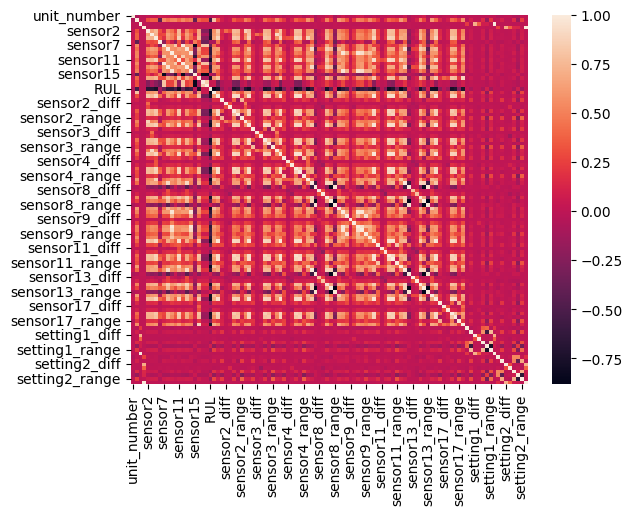

In [22]:
sns.heatmap(data.corr(),annot=False)

In [23]:
data.shape

(24720, 102)

In [24]:
data.drop(['time_in_cycles'],inplace=True,axis=1)

In [25]:
data

,unit_number,setting1,setting2,sensor2,sensor3,sensor4,sensor6,sensor7,sensor8,sensor9,...,setting1_range,setting1_norm,setting2_mean,setting2_std,setting2_diff,setting2_slope,setting2_max,setting2_min,setting2_range,setting2_norm
0,1,-0.0005,0.0004,642.36,1583.23,1396.84,21.61,553.97,2387.96,9062.17,...,0.0000,-0.251882,4.000000e-04,0.000000,0.0000,0.000000,0.0004,0.0004,0.0000,1.511197
1,1,0.0008,-0.0003,642.50,1584.69,1396.89,21.61,554.55,2388.00,9061.78,...,0.0013,0.292462,5.000000e-05,0.000495,-0.0007,-0.000700,0.0004,-0.0003,0.0007,-0.840563
2,1,-0.0014,-0.0002,642.18,1582.35,1405.61,21.61,554.43,2388.03,9070.23,...,0.0022,-0.628736,-3.333333e-05,0.000379,0.0001,-0.000300,0.0004,-0.0003,0.0007,-0.504597
3,1,-0.0020,0.0001,642.92,1585.61,1392.27,21.61,555.21,2388.00,9064.57,...,0.0028,-0.879972,1.016440e-20,0.000316,0.0003,-0.000100,0.0004,-0.0003,0.0007,0.503300
4,1,0.0016,0.0000,641.68,1588.63,1397.65,21.61,554.74,2388.04,9076.14,...,0.0036,0.627443,8.131516e-21,0.000274,-0.0001,-0.000100,0.0004,-0.0003,0.0007,0.167334
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24715,100,-0.0016,-0.0003,643.78,1596.01,1424.11,21.61,551.86,2388.25,9070.82,...,0.0107,-0.807508,-3.000000e-05,0.000248,-0.0004,-0.000020,0.0003,-0.0005,0.0008,-0.966070
24716,100,0.0034,-0.0003,643.29,1596.38,1429.14,21.61,551.86,2388.23,9064.60,...,0.0107,1.414455,-4.000000e-05,0.000253,0.0000,-0.000010,0.0003,-0.0005,0.0008,-0.966070
24717,100,-0.0016,0.0004,643.84,1604.53,1431.41,21.61,551.30,2388.25,9063.45,...,0.0107,-0.807508,-3.333333e-05,0.000262,0.0007,0.000007,0.0004,-0.0005,0.0009,1.597268
24718,100,-0.0023,0.0004,643.94,1597.56,1426.57,21.61,550.69,2388.26,9062.22,...,0.0107,-1.118583,-2.666667e-05,0.000270,0.0000,0.000007,0.0004,-0.0005,0.0009,1.597268


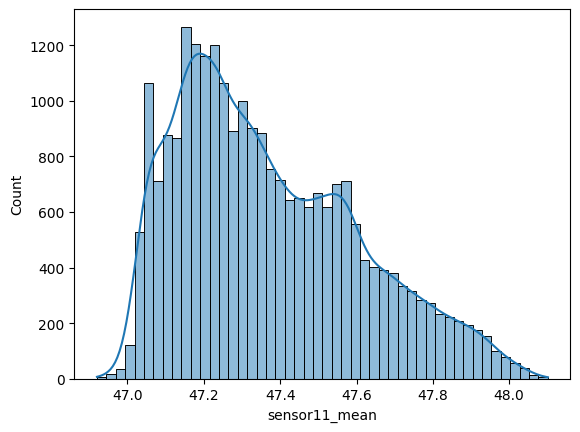

In [26]:
sns.histplot(data['sensor11_mean'],kde=True)
plt.show()

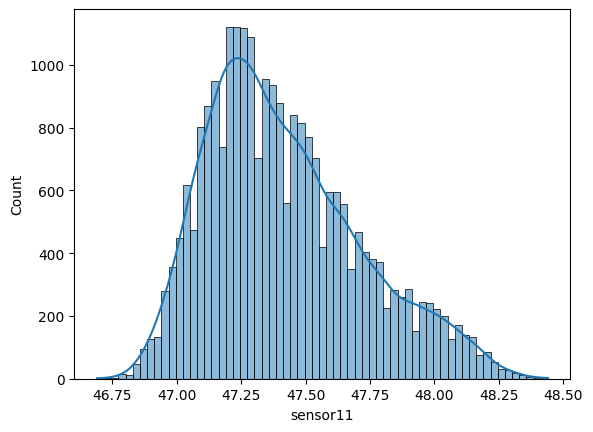

In [27]:
sns.histplot(data['sensor11'],kde=True)
plt.show()

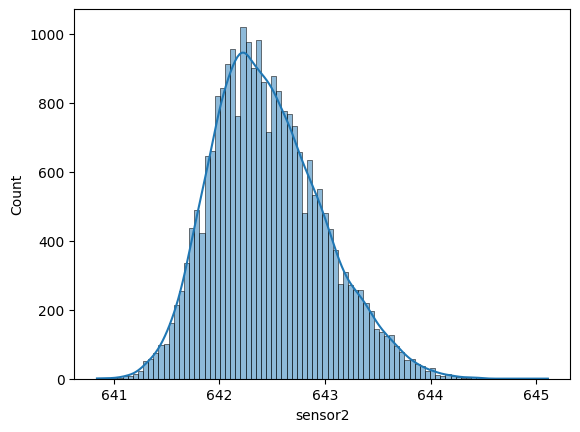

In [28]:
sns.histplot(data['sensor2'],kde=True)
plt.show()

In [29]:
raw_sensors = ['sensor2', 'sensor3', 'sensor4', 'sensor7', 'sensor8',
               'sensor9', 'sensor11', 'sensor12', 'sensor13', 'sensor14',
               'sensor15', 'sensor17', 'sensor20', 'sensor21']

corr_matrix = data.corr()["RUL"].abs().sort_values(ascending=False)

top_engineered = [col for col in corr_matrix.index if col != "RUL" and col not in raw_sensors][:25]

final_features = list(set(raw_sensors + top_engineered + ['setting1', 'setting2', 'cycle_norm']))


print(f"Total Features selected: {len(final_features)}")
print("Selected Features:", final_features)


X = data[final_features]
y = data["RUL"]

Total Features selected: 41
Selected Features: ['sensor11_max', 'sensor21', 'sensor2_norm', 'sensor13', 'sensor8_norm', 'sensor17_max', 'sensor4_mean', 'sensor11_mean', 'sensor2', 'sensor12', 'sensor8_max', 'sensor4_max', 'sensor8', 'sensor17_norm', 'sensor20', 'sensor4_min', 'sensor9', 'sensor3_max', 'sensor9_max', 'sensor3_min', 'sensor2_max', 'sensor17_min', 'sensor3', 'sensor17', 'cycle_norm', 'sensor13_max', 'sensor2_mean', 'setting2', 'sensor11_norm', 'sensor7', 'sensor4', 'sensor11', 'sensor17_mean', 'sensor4_norm', 'sensor3_mean', 'sensor14', 'sensor15', 'sensor13_norm', 'setting1', 'sensor3_norm', 'sensor11_min']


In [30]:
x_train, x_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42)
y_train = y_train.clip(upper=135)

In [31]:
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [32]:
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

In [33]:
model = RandomForestRegressor(
    n_estimators=600,
    max_depth=15,
    min_samples_leaf=8,
    max_features="sqrt",
    bootstrap=True,
    random_state=42,
    n_jobs=-1
)

model.fit(x_train, y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",600
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",15
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",8
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsampl

In [34]:
y_pred_randomforest = model.predict(x_test)

In [35]:
rmse = mean_squared_error(y_test, y_pred_randomforest) ** 0.5
r2 = r2_score(y_test, y_pred_randomforest)

print("RMSE:", rmse)
print("R2 Score:", r2)
print("MAE:", mean_absolute_error(y_test, y_pred_randomforest))
print("Train", model.score(x_train, y_train))
print("Test", model.score(x_test, y_test))

RMSE: 8.054700804819838
R2 Score: 0.9602047323195422
MAE: 5.2410273296859256
Train 0.9768542566011521
Test 0.9602047323195422


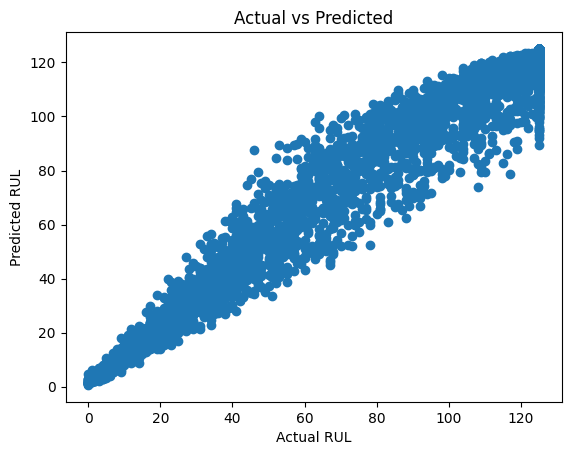

In [36]:
plt.scatter(y_test, y_pred_randomforest)
plt.xlabel("Actual RUL")
plt.ylabel("Predicted RUL")
plt.title("Actual vs Predicted")
plt.show()

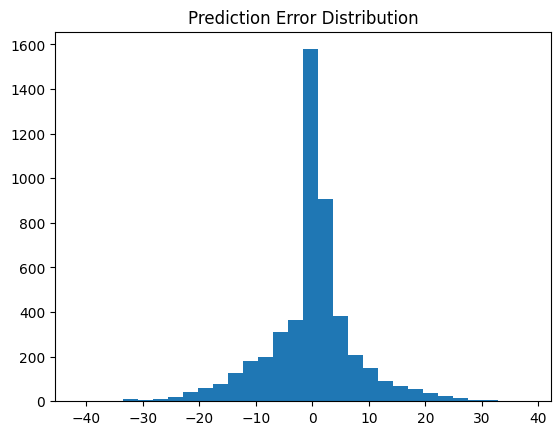

In [37]:
error = y_test - y_pred_randomforest

plt.hist(error, bins=30)
plt.title("Prediction Error Distribution")
plt.show()

In [38]:
import joblib as jp
jp.dump(model,'model_FD003.pkl')
jp.dump(scaler,'scaler_FD003.pkl')
jp.dump(important_sensors,'important_sensors_FD003.pkl')
jp.dump(final_features,'features_FD003.pkl')

['features_FD003.pkl']

In [39]:
test = pd.read_csv('test_FD003.txt', sep=' ', header=None)
columns = ["unit_number","time_in_cycles",
           "setting1","setting2","setting3"] + \
          [f"sensor{i}" for i in range(1,22)]

test = test.iloc[:, :len(columns)]
test.columns = columns
test.to_csv('test_FD003.csv', index=False)

In [40]:
rul = pd.read_csv('RUL_FD003.txt', header=None, delim_whitespace=True)
rul.to_csv('RUL_FD003.csv',index=False)
rul.columns = ['RUL']

C:\Users\HP\AppData\Local\Temp\ipykernel_8172\198142368.py:1: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  rul = pd.read_csv('RUL_FD003.txt', header=None, delim_whitespace=True)


In [41]:
test.isna().sum().sum()

np.int64(0)

In [42]:
test.duplicated().sum().sum()

np.int64(0)

In [43]:
for column in test.columns:
  print(column,":",test[column].nunique())
  if test[column].nunique() == 1:
    test.drop(column,axis=1,inplace=True)

unit_number : 100
time_in_cycles : 475
setting1 : 150
setting2 : 13
setting3 : 1
sensor1 : 1
sensor2 : 274
sensor3 : 2687
sensor4 : 3250
sensor5 : 1
sensor6 : 7
sensor7 : 1339
sensor8 : 153
sensor9 : 4750
sensor10 : 3
sensor11 : 147
sensor12 : 1277
sensor13 : 155
sensor14 : 4233
sensor15 : 2128
sensor16 : 1
sensor17 : 12
sensor18 : 1
sensor19 : 1
sensor20 : 133
sensor21 : 4439


In [44]:
max_cycle = test.groupby("unit_number")["time_in_cycles"].transform("max")
test["cycle_norm"] = test["time_in_cycles"] / max_cycle

In [45]:
data["RUL"] = data["RUL"].clip(upper=125)

In [46]:
important_sensors = jp.load('important_sensors_FD003.pkl')

In [47]:
test = test.sort_values(["unit_number", "time_in_cycles"])

In [48]:
window = 30

def get_features(df, sensors_cols):

    df = df.sort_values(['unit_number', 'time_in_cycles'])

    for col in sensors_cols:

        df[col+"_mean"] = df.groupby("unit_number")[col].transform(
            lambda x: x.rolling(window, min_periods=1).mean()
        )
        df[col+"_std"] = df.groupby("unit_number")[col].transform(
            lambda x: x.rolling(window, min_periods=1).std()
        ).fillna(0)

        df[col+"_diff"] = df.groupby("unit_number")[col].transform(
            lambda x: x.diff().fillna(0)
        )
        df[col+"_slope"] = df.groupby("unit_number")[col].transform(
            lambda x: x.diff().rolling(window, min_periods=1).mean()
        ).fillna(0)


        df[col+"_max"] = df.groupby("unit_number")[col].transform(
            lambda x: x.rolling(window, min_periods=1).max()
        )
        df[col+"_min"] = df.groupby("unit_number")[col].transform(
            lambda x: x.rolling(window, min_periods=1).min()
        )


        df[col+"_range"] = df[col+"_max"] - df[col+"_min"]


        df[col+"_norm"] = df.groupby("unit_number")[col].transform(
            lambda x: (x - x.mean()) / (x.std() + 1e-5)
        )

    return df

test = get_features(test, important_sensors)



In [49]:
final_features = jp.load('features_FD003.pkl')
scaler = jp.load('scaler_FD003.pkl')
model = jp.load('model_FD003.pkl')

In [50]:
last_5_cycles = test.groupby("unit_number").tail(5)
X_test_final_raw = last_5_cycles.groupby("unit_number")[final_features].mean().reset_index()
X_test_final_raw = X_test_final_raw.sort_values("unit_number")

X_test_ready = X_test_final_raw[final_features]

X_test_final_scaled = scaler.transform(X_test_ready)
y_pred_test = model.predict(X_test_final_scaled)
y_pred_test = np.clip(y_pred_test, 0, 125)

results = pd.DataFrame({
    "unit_number": X_test_final_raw["unit_number"],
    "pred": y_pred_test
})

results = results.merge(rul, left_on="unit_number", right_index=True, how='left')

results["RUL"] = results["RUL"].clip(upper=125)

In [51]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np

In [52]:
print("predictions:", len(y_pred_test))
print("true RUL:", len(rul))

predictions: 100
true RUL: 100


In [53]:
print(y_pred_test[:10])
print(rul.head(10))

[42.64503947 32.01331983 25.69688802 66.77015963 98.35349679 64.66434651
 31.12629359 26.57267851 39.03670887 72.58578246]
   RUL
0   44
1   51
2   27
3  120
4  101
5   99
6   71
7   55
8   55
9   66


In [55]:
y_pred_final_tune = y_pred_test.copy()

for i in range(len(y_pred_final_tune)):
    if 30 < y_pred_final_tune[i] <= 70:
        y_pred_final_tune[i] *= 1.15

    elif y_pred_final_tune[i] > 70:
        y_pred_final_tune[i] *= 1.18

y_pred_final_tune = np.clip(y_pred_final_tune, 0, 135)
y_true = rul['RUL'].clip(upper=135).values
tuned_rmse = np.sqrt(mean_squared_error(y_true, y_pred_final_tune))
tuned_r2 = r2_score(y_true, y_pred_final_tune)

print(f" Tuned RMSE: {tuned_rmse:.2f}")
print(f" Tuned R2 Score: {tuned_r2:.4f}")

 Tuned RMSE: 23.57
 Tuned R2 Score: 0.6650


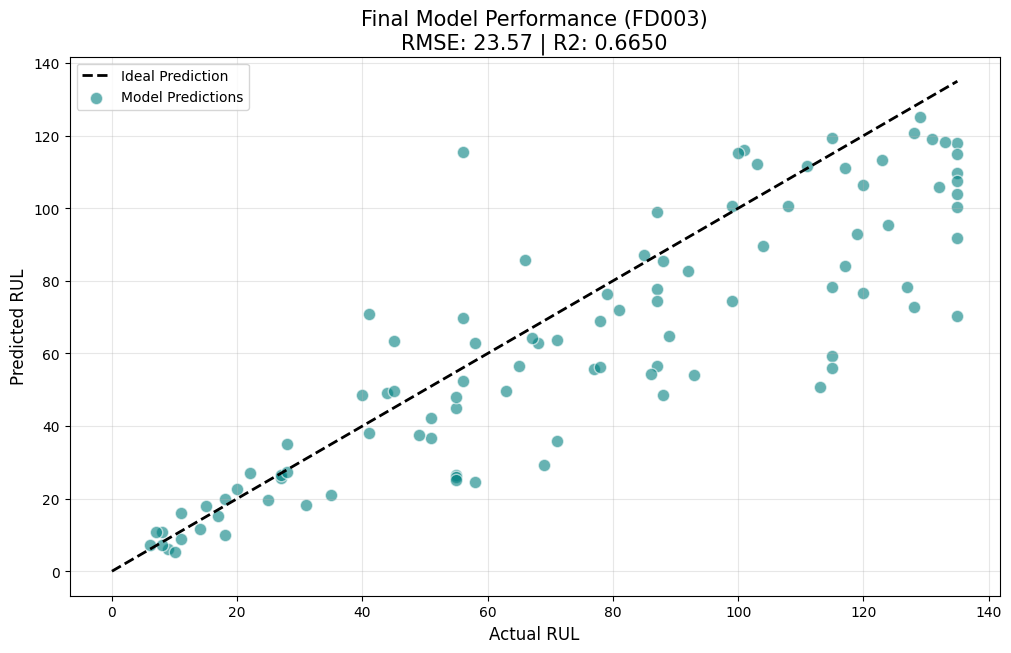

In [56]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(12, 7))
plt.plot([0, 135], [0, 135], 'k--', lw=2, label='Ideal Prediction')
plt.scatter(y_true, y_pred_final_tune, alpha=0.6, edgecolors='w', color='teal', s=80, label='Model Predictions')
plt.title(f'Final Model Performance (FD003)\nRMSE: {tuned_rmse:.2f} | R2: {tuned_r2:.4f}', fontsize=15)
plt.xlabel('Actual RUL', fontsize=12)
plt.ylabel('Predicted RUL', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()